<a href="https://colab.research.google.com/github/kajhdsjdn/Flower-MLOps/blob/main/Llava_demo_4bit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Running Llava: a large multi-modal model on Google Colab

Run Llava model on a Google Colab!

Llava is a multi-modal image-text to text model that can be seen as an "open source version of GPT4". It yields to very nice results as we will see in this Google Colab demo.

![image/png](https://cdn-uploads.huggingface.co/production/uploads/62441d1d9fdefb55a0b7d12c/FPshq08TKYD0e-qwPLDVO.png)

The architecutre is a pure decoder-based text model that takes concatenated vision hidden states with text hidden states.

We will leverage QLoRA quantization method and use `pipeline` to run our model.

In [1]:
!pip install -q -U "transformers==4.49.0" "accelerate>=0.26.0" "bitsandbytes>=0.45.0" "huggingface-hub>=0.28.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 122.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 121.3 MB/s eta 0:00:00


## Load an image

Let's use the image that has been used for Llava demo

And ask the model to describe that image!

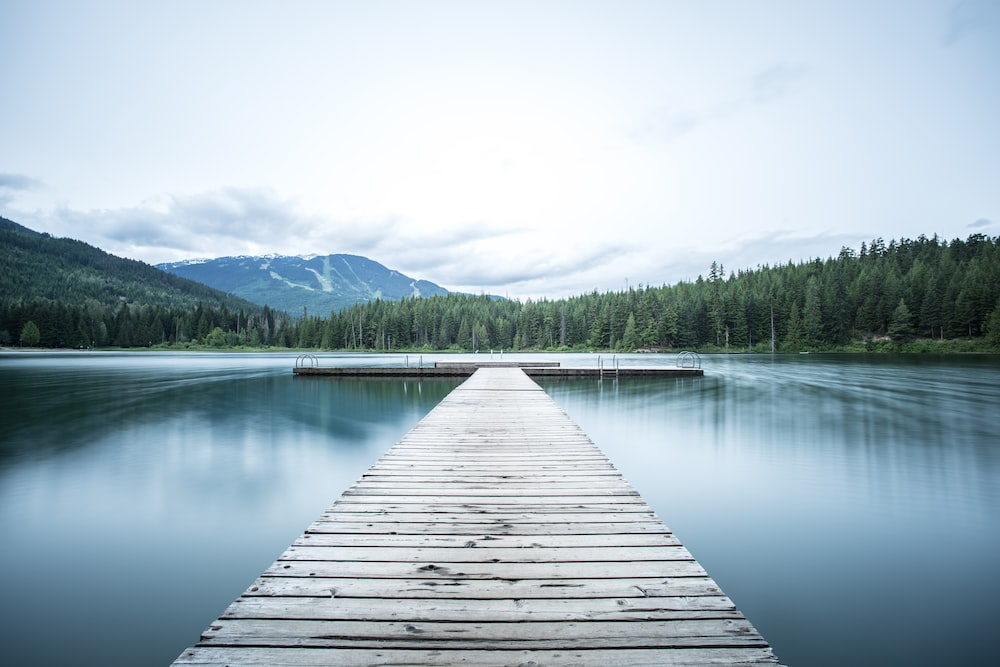

In [2]:
import requests
from PIL import Image

image_url = "https://llava-vl.github.io/static/images/view.jpg"
image = Image.open(requests.get(image_url, stream=True).raw)
image

## Preparing the quantization config to load the model in 4bit precision

In order to load the model in 4-bit precision, we need to pass a `quantization_config` to our model. Let's do that in the cells below

In [3]:
import torch
from transformers import BitsAndBytesConfig

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)

## Load the model using `pipeline`

We will leverage the `image-to-text` pipeline from transformers !

In [4]:
from transformers import pipeline

model_id = "llava-hf/llava-1.5-7b-hf"

pipe = pipeline("image-to-text", model=model_id, model_kwargs={"quantization_config": quantization_config})

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

`low_cpu_mem_usage` was None, now default to True since model is quantized.


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

...

added_tokens.json:   0%|          | 0.00/41.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/674 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cuda:0


It is important to prompt the model wth a specific format, which is:
```bash
USER: <image>\n<prompt>\nASSISTANT:
```

In [5]:
max_new_tokens = 200
prompt = "USER: <image>\nWhat are the things I should be cautious about when I visit this place?\nASSISTANT:"

outputs = pipe(image, prompt=prompt, generate_kwargs={"max_new_tokens": 200})

Passing `prompt` to the `image-to-text` pipeline is deprecated and will be removed in version 4.48 of 🤗 Transformers. Use the `image-text-to-text` pipeline instead


ValueError: Image features and image tokens do not match: tokens: 1, features 576

In [ ]:
print(outputs[0]["generated_text"])

USER:  
What are the things I should be cautious about when I visit this place?
ASSISTANT: When visiting this place, which is a pier or dock extending over a body of water, there are a few things to be cautious about. First, be aware of the weather conditions, as sudden changes in weather can make the pier unsafe to walk on. Second, be mindful of the water depth and any potential hazards, such as submerged rocks or debris, that could cause accidents or injuries. Additionally, be cautious of the presence of wildlife, such as birds or fish, and avoid disturbing their natural habitats. Lastly, be aware of any local regulations or guidelines for the use of the pier, as some areas may be restricted or prohibited for certain activities.


In [6]:
from transformers import pipeline

llava_pipe = pipeline(
    "image-text-to-text",
    model="llava-hf/llava-1.5-7b-hf",
    model_kwargs={
        "quantization_config": quantization_config
    }
)

`low_cpu_mem_usage` was None, now default to True since model is quantized.


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

Device set to use cuda:0


In [7]:
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image
            },
            {
                "type": "text",
                "text": "What are the things I should be cautious about when I visit this place?"
            }
        ]
    }
]

outputs = llava_pipe(
    text=messages,
    max_new_tokens=200
)

print(outputs)

Keyword argument `legacy` is not a valid argument for this processor and will be ignored.


[{'input_text': [{'role': 'user', 'content': [{'type': 'image', 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1000x667 at 0x79DDAEE7A7B0>}, {'type': 'text', 'text': 'What are the things I should be cautious about when I visit this place?'}]}], 'generated_text': [{'role': 'user', 'content': [{'type': 'image', 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1000x667 at 0x79DDAEE7A7B0>}, {'type': 'text', 'text': 'What are the things I should be cautious about when I visit this place?'}]}, {'role': 'assistant', 'content': ' When visiting this place, which is a pier or dock extending over a body of water, there are a few things to be cautious about. First, be aware of the weather conditions, as sudden changes in weather can make the pier unsafe to walk on. Second, be mindful of the water depth and any potential hazards, such as submerged rocks or debris, that could cause accidents or injuries. Additionally, be cautious of the tides and currents, as they can

In [8]:
from google.colab import files

uploaded = files.upload()

Saving ChatGPT Image Aug 10, 2026, 01_44_47 PM.png to ChatGPT Image Aug 10, 2026, 01_44_47 PM.png


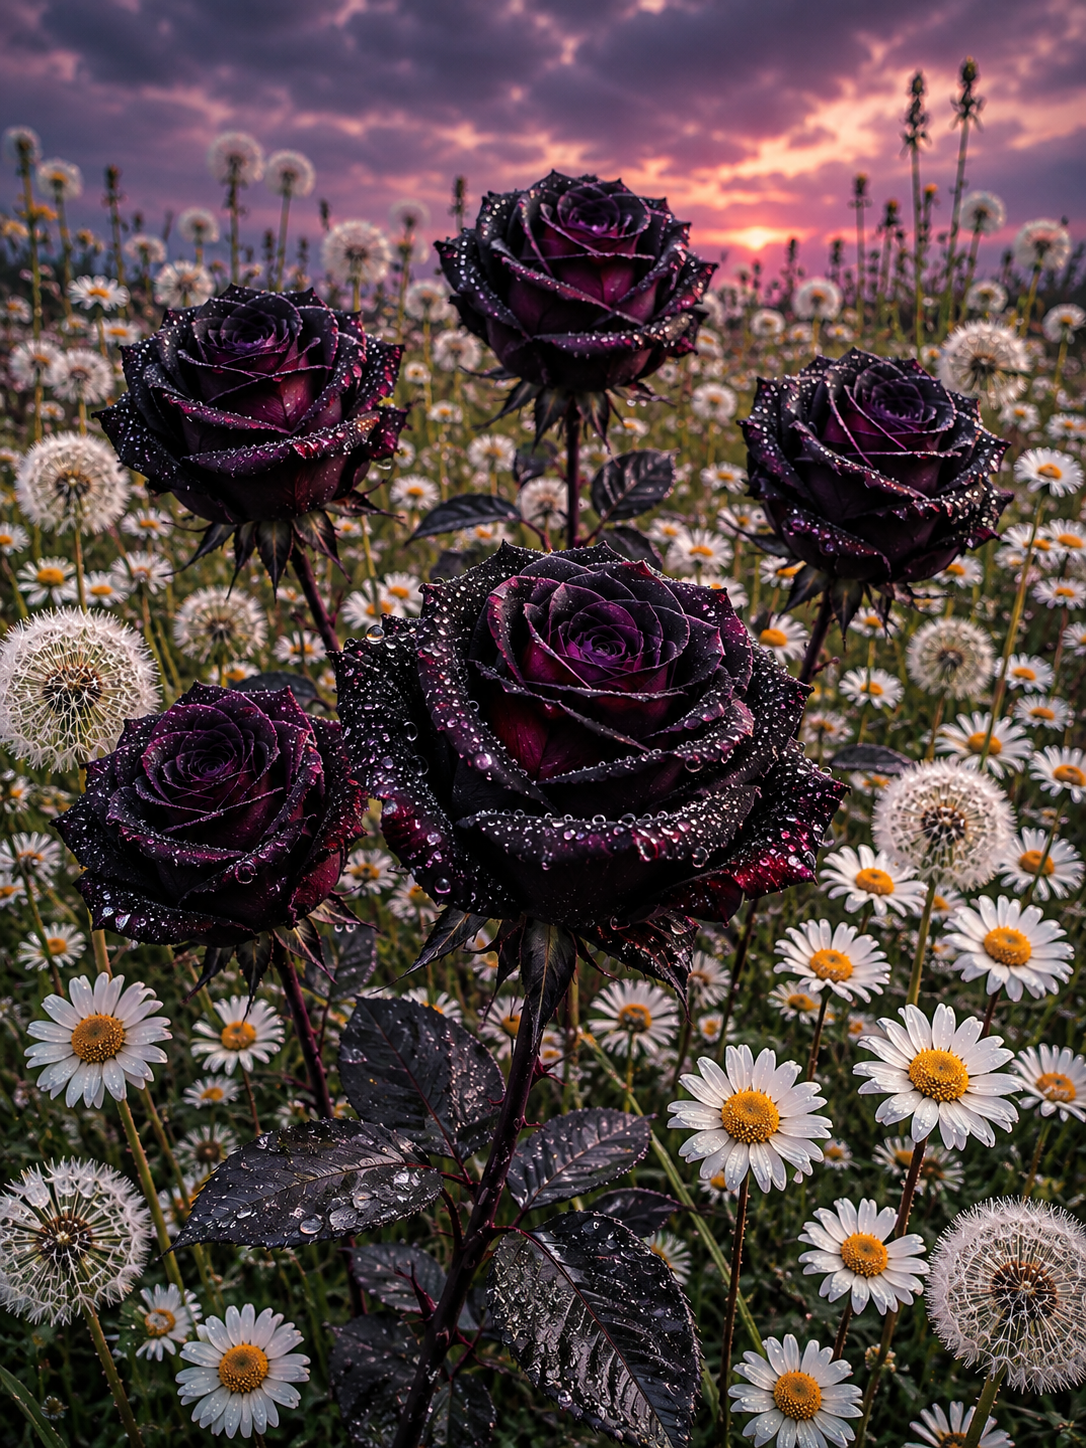

In [9]:
from PIL import Image
import io

filename = list(uploaded.keys())[0]

image = Image.open(filename).convert("RGB")

display(image)

In [15]:
conversation = [
    {
        "role": "user",
        "content": [
            {
                "type": "text",
                "text": """Analyze this image carefully.

Identify all visible flowers.
The possible flower types are:
rose, tulip, sunflower, daisy, dandelion.

List every flower type you can identify."""
            },
            {
                "type": "image"
            }
        ]
    }
]

prompt = processor.apply_chat_template(
    conversation,
    add_generation_prompt=True
)

inputs = processor(
    images=image,
    text=prompt,
    return_tensors="pt"
)

inputs = {
    k: v.to("cuda") if hasattr(v, "to") else v
    for k, v in inputs.items()
}

output = model.generate(
    **inputs,
    max_new_tokens=150
)

answer = processor.decode(
    output[0],
    skip_special_tokens=True
)

print(answer)

USER:  
Analyze this image carefully.

Identify all visible flowers.
The possible flower types are:
rose, tulip, sunflower, daisy, dandelion.

List every flower type you can identify. ASSISTANT: The image features a beautiful field of flowers, including a group of purple roses. The field is filled with various types of flowers, creating a vibrant and colorful scene. The purple roses stand out among the other flowers, adding a touch of elegance to the overall composition.


In [16]:
conversation = [
    {
        "role": "user",
        "content": [
            {
                "type": "text",
                "text": """You are analyzing a flower image.

The ONLY flower classes are:
1. rose
2. tulip
3. sunflower
4. daisy
5. dandelion

Carefully inspect the entire image from left to right and top to bottom.

For EACH flower class:
- Count the individual flowers you can see.
- Do not ignore small flowers.
- Do not count the same flower twice.

Return the result exactly in this format:

Rose: X
Tulip: X
Sunflower: X
Daisy: X
Dandelion: X

Total flowers: X"""
            },
            {
                "type": "image"
            }
        ]
    }
]

prompt = processor.apply_chat_template(
    conversation,
    add_generation_prompt=True
)

inputs = processor(
    images=image,
    text=prompt,
    return_tensors="pt"
)

inputs = {
    k: v.to("cuda") if hasattr(v, "to") else v
    for k, v in inputs.items()
}

output = model.generate(
    **inputs,
    max_new_tokens=200
)

answer = processor.decode(
    output[0],
    skip_special_tokens=True
)

print(answer)

USER:  
You are analyzing a flower image.

The ONLY flower classes are:
1. rose
2. tulip
3. sunflower
4. daisy
5. dandelion

Carefully inspect the entire image from left to right and top to bottom.

For EACH flower class:
- Count the individual flowers you can see.
- Do not ignore small flowers.
- Do not count the same flower twice.

Return the result exactly in this format:

Rose: X
Tulip: X
Sunflower: X
Daisy: X
Dandelion: X

Total flowers: X ASSISTANT: Rose: 3
Tulip: 0
Sunflower: 0
Daisy: 10
Dandelion: 0


The model has managed to successfully describe the image with accurate result ! We also support other variants of Llava, such as [`bakLlava`](https://huggingface.co/llava-hf/bakLlava-v1-hf) which should be all posted inside the [`llava-hf`](https://huggingface.co/llava-hf) organization on 🤗 Hub